# AOI Visualization

Two-part notebook:

**Part 1 — Global AOI Coverage Map**  
Static world map showing the geographic spread of all reference cities in the dataset inventory, coloured by data coverage status.

**Part 2 — Per-City Tile Density Map**  
Tessellates a chosen city's AOI into 1 km × 1 km tiles, counts reference buildings per tile, and colours by building density class (High / Medium / Low).

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
# Install optional visualisation dependencies (safe to re-run)
import subprocess, sys

def _pip(*pkgs):
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *pkgs])

try:
    import contextily
except ImportError:
    _pip("contextily")

try:
    from matplotlib_scalebar.scalebar import ScaleBar
except ImportError:
    _pip("matplotlib-scalebar")

try:
    import pycountry
except ImportError:
    _pip("pycountry")

try:
    import geodatasets
except ImportError:
    _pip("geodatasets")

In [3]:
import os, sys

PROJECT_ROOT = "/content/drive/MyDrive/Gates Foundation/Building Dataset Validation"
os.chdir(PROJECT_ROOT)
if PROJECT_ROOT not in sys.path:
    sys.path.insert(0, PROJECT_ROOT)

In [4]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Change CITY_ID to any city that appears in data/02_interim/aoi_tracker.csv.
# Good options with varied density: "gha-accra", "ken-nairobi", "sle-freetown",
# "uga-kampala", "zaf-capetown".

# CITY_ID     = "gha-accra"
CITY_ID     = "ssd-juba"

TILE_SIZE_M = 1000   # 1 km × 1 km
MIN_AREA_M2 = 20     # discard footprints smaller than this (matches pipeline default)

In [5]:
from pathlib import Path
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib_scalebar.scalebar import ScaleBar

try:
    import contextily as ctx
    HAS_CTX = True
except ImportError:
    HAS_CTX = False
    print("contextily not found — basemap tiles will be skipped in the static map.")

import folium
from folium.plugins import MiniMap

from src.utils.buildings import load_aoi, load_buildings
from src.utils.tiling import make_tiles
from src.utils.geometry import get_projected_crs

ROOT       = Path(PROJECT_ROOT)
DATA_DIR   = ROOT / "data" / "01_raw"
TRACKER    = ROOT / "data" / "02_interim" / "aoi_tracker.csv"


def format_city_label(city_id: str) -> str:
    """Convert 'gha-accra' -> 'Accra, Ghana', 'ssd-juba' -> 'Juba, South Sudan'."""
    parts = city_id.split("-", 1)
    if len(parts) != 2:
        return city_id.replace("-", " ").title()
    country_code, city_slug = parts
    city_name = " ".join(w.capitalize() for w in city_slug.split("-"))
    try:
        import pycountry
        country = pycountry.countries.get(alpha_3=country_code.upper())
        country_name = country.name if country else country_code.upper()
    except Exception:
        country_name = country_code.upper()
    return f"{city_name}, {country_name}"


print("Imports OK")

Imports OK


---
## Part 1 — Global AOI Coverage Map

Reads the AOI tracker, loads each city's AOI boundary to extract its centroid (falls back to a country-level centroid when the file is missing), and plots a static world map coloured by data coverage status.

In [6]:
# ── Country-level centroid fallback (from src/plots/visualize.py) ──────────────
_COUNTRY_CENTROIDS = {
    "afg": (34.53,  69.17), "ant": (12.10, -68.90), "bgd": (23.70,  90.40),
    "blz": (17.30, -88.50), "bra": (-12.90,-38.40), "col": ( 6.20, -75.60),
    "cvg": (13.20, -61.20), "dom": (15.40, -61.40), "gha": ( 7.90,  -1.00),
    "grd": (12.10, -61.70), "jam": (18.00, -76.80), "jpn": (35.70, 139.70),
    "ken": ( 1.30,  38.00), "lbr": ( 6.30, -10.80), "lby": (27.00,  17.00),
    "lca": (13.90, -60.90), "maf": (18.10, -63.10), "mmr": (21.90,  96.10),
    "moz": (-18.70, 35.50), "mwi": (-13.30, 34.30), "ner": (13.50,   2.10),
    "nga": ( 7.40,   3.90), "phl": (11.80, 122.10), "sle": ( 8.50, -13.20),
    "ssd": ( 4.90,  31.60), "swz": (-26.50, 31.50), "sxm": (18.00, -63.10),
    "tjk": (39.00,  71.00), "ton": (-21.10,-175.20), "tto": (10.40, -61.30),
    "uga": ( 1.40,  32.30), "ukr": (50.90,  28.10),
}

def _truthy(v) -> bool:
    if pd.isna(v): return False
    if isinstance(v, bool): return v
    if isinstance(v, (int, float)): return v != 0
    return str(v).strip().lower() in {"true", "1", "yes", "y", "t"}

# ── Load tracker ───────────────────────────────────────────────────────────────
_df = pd.read_csv(TRACKER, dtype=str)
_df.columns = _df.columns.str.strip()

# City ID column (handles different tracker versions)
_id_col = next(
    (c for c in _df.columns if c in {"dataset_folder_name", "Dataset code"}),
    _df.columns[0],
)

# Suitable filter
_sc = next((c for c in _df.columns if "suitable" in c.lower()), None)
if _sc:
    _df = _df[_df[_sc].astype(str).str.lower() == "yes"].copy()

# Coverage-status columns (present in some tracker versions)
_hac = "has_aoi_file"       if "has_aoi_file"       in _df.columns else None
_hrc = "has_reference_file" if "has_reference_file" in _df.columns else None

# ── Resolve one centroid per city ─────────────────────────────────────────────
records = []
for city_id in sorted(_df[_id_col].dropna().unique()):
    city_id = str(city_id).strip()
    if not city_id:
        continue

    # Status
    grp = _df[_df[_id_col] == city_id]
    if _hac and _hrc:
        has_aoi = any(_truthy(v) for v in grp[_hac])
        has_ref = any(_truthy(v) for v in grp[_hrc])
        status  = "full" if has_aoi and has_ref else "partial"
    else:
        status = "full"

    # Centroid from AOI file(s)
    lat = lon = None
    aoi_dir = DATA_DIR / city_id / "aoi"
    if aoi_dir.exists():
        found = sorted(aoi_dir.glob("*.geojson")) + sorted(aoi_dir.glob("*.gpkg"))
        if found:
            try:
                parts = [gpd.read_file(p) for p in found[:8]]
                gdf   = gpd.GeoDataFrame(pd.concat(parts, ignore_index=True), crs=parts[0].crs)
                if gdf.crs and not gdf.crs.is_geographic:
                    gdf = gdf.to_crs("EPSG:4326")
                c    = gdf.geometry.union_all().centroid
                lat, lon = c.y, c.x
            except Exception:
                pass

    # Fallback: country-level centroid
    if lat is None:
        lat, lon = _COUNTRY_CENTROIDS.get(city_id[:3].lower(), (None, None))

    if lat is not None:
        records.append({"city_id": city_id, "status": status, "lat": lat, "lon": lon})

city_gdf = gpd.GeoDataFrame(
    records,
    geometry=gpd.points_from_xy([r["lon"] for r in records], [r["lat"] for r in records]),
    crs="EPSG:4326",
)

n_full    = (city_gdf["status"] == "full").sum()
n_partial = (city_gdf["status"] == "partial").sum()
print(f"Cities mapped : {len(city_gdf)}")
print(f"Full coverage : {n_full}")
print(f"Partial       : {n_partial}")

Cities mapped : 85
Full coverage : 85
Partial       : 0


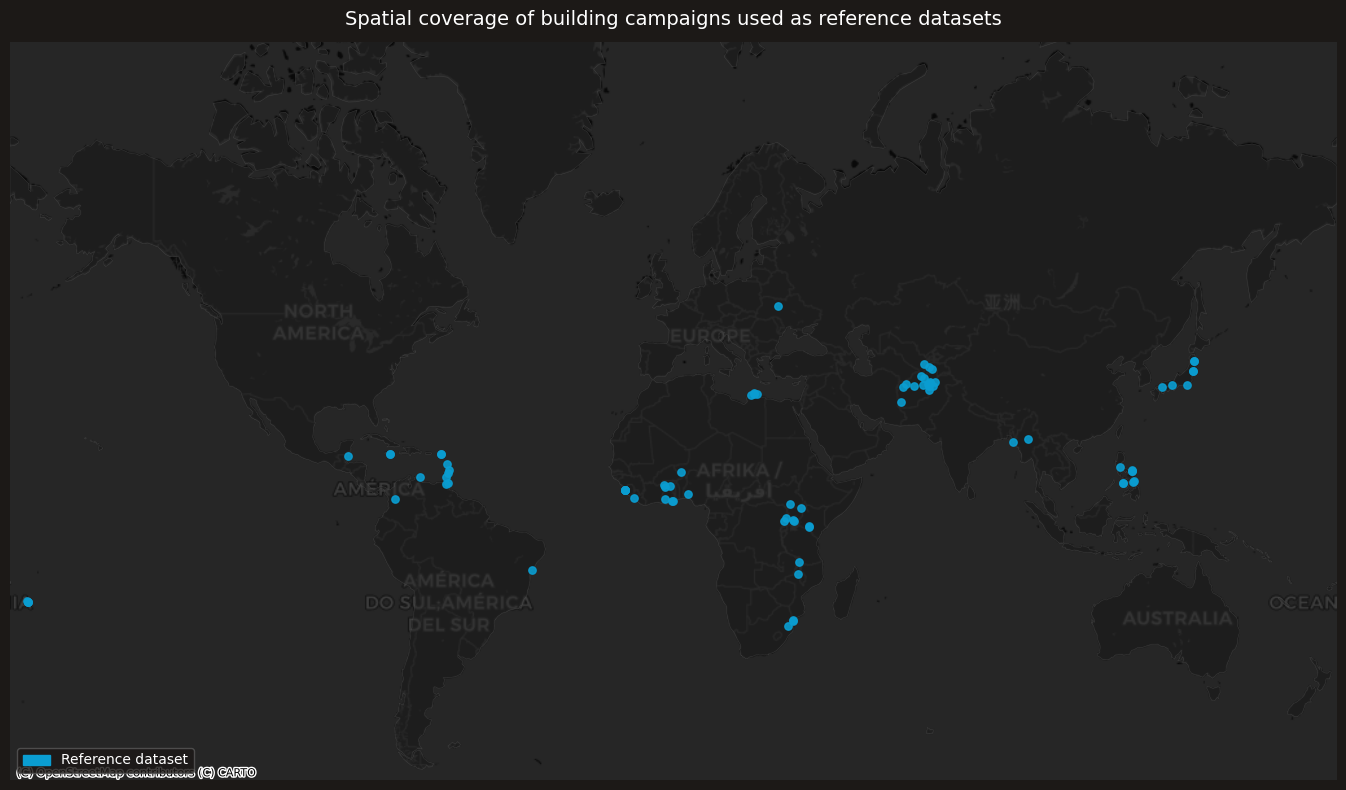

In [7]:
# ── Load world basemap polygons ───────────────────────────────────────────────
_world = None

try:
    import geodatasets
    _world = gpd.read_file(geodatasets.get_path("naturalearth.land"))
except Exception:
    pass

if _world is None:
    try:
        _world = gpd.read_file(gpd.datasets.get_path("naturalearth_lowres"))
    except Exception:
        pass

if _world is None:
    _NE_URL = (
        "https://naciscdn.org/naturalearth/110m/cultural/"
        "ne_110m_admin_0_countries.zip"
    )
    _world = gpd.read_file(_NE_URL)

# ── Reproject to Web Mercator for contextily ──────────────────────────────────
city_3857  = city_gdf.to_crs("EPSG:3857")
world_3857 = _world.to_crs("EPSG:3857")

# Approximate EPSG:3857 bounds for lat [-58°, 80°] / lon [-180°, 180°]
_X_MIN, _X_MAX = -20_037_508,  20_037_508
_Y_MIN, _Y_MAX =  -7_800_000,  14_500_000

_STATUS_COLORS = {"full": "#0a9dd1", "partial": "#f4a800"}
_STATUS_LABELS = {"full": "Reference dataset", "partial": "Partial coverage"}

fig, ax = plt.subplots(figsize=(18, 8))
fig.patch.set_facecolor("#1c1917")
ax.set_facecolor("#1c1917")   # fallback ocean colour if basemap fails

# Land polygons — subtle overlay so country outlines remain legible
world_3857.plot(
    ax=ax,
    color="#2e2e2e",
    edgecolor="#555555",
    linewidth=0.35,
    alpha=0.55,
    zorder=1,
)

for status, grp in city_3857.groupby("status"):
    grp.plot(
        ax=ax,
        color=_STATUS_COLORS[status],
        markersize=28,
        alpha=0.9,
        zorder=3,
        label=_STATUS_LABELS[status],
    )

ax.set_xlim(_X_MIN, _X_MAX)
ax.set_ylim(_Y_MIN, _Y_MAX)

# CartoDB dark_matter basemap
if HAS_CTX:
    try:
        ctx.add_basemap(
            ax,
            source=ctx.providers.CartoDB.DarkMatter,
            zoom="auto",
        )
    except Exception as e:
        print(f"Basemap failed ({e}); continuing without.")

ax.set_axis_off()

# Legend
_handles = [
    mpatches.Patch(color=_STATUS_COLORS[s], label=_STATUS_LABELS[s])
    for s in ["full", "partial"]
    if s in city_gdf["status"].values
]
ax.legend(
    handles=_handles,
    loc="lower left",
    fontsize=10,
    framealpha=0.85,
    facecolor="#1c1917",
    edgecolor="#555555",
    labelcolor="white",
)

ax.set_title(
    "Spatial coverage of building campaigns used as reference datasets",
    fontsize=14,
    pad=12,
    color="white",
)

plt.tight_layout()
plt.show()

---
## Part 2 — Per-City Tile Density Map

Set `CITY_ID` in the configuration cell below to any city in the tracker.

## 1. Resolve file paths from the AOI tracker

In [8]:
tracker = pd.read_csv(TRACKER, dtype=str)
tracker.columns = tracker.columns.str.strip()

city_rows = tracker[tracker["dataset_folder_name"].str.strip() == CITY_ID]
if city_rows.empty:
    raise ValueError(f"{CITY_ID!r} not found in tracker. Check CITY_ID.")

# AOI files (may be pipe-separated for multi-AOI cities)
aoi_file_raw = city_rows["aoi_file_name"].iloc[0]
aoi_files    = [f.strip() for f in str(aoi_file_raw).split("|") if f.strip()]
aoi_paths    = [DATA_DIR / CITY_ID / "aoi" / f for f in aoi_files]

# Reference building file(s)
ref_col   = next(c for c in tracker.columns if "reference" in c.lower() and "file" in c.lower())
ref_raw   = city_rows[ref_col].iloc[0]
ref_files = [f.strip() for f in str(ref_raw).split("|") if f.strip()]
ref_paths = [DATA_DIR / CITY_ID / "vector" / f for f in ref_files]

missing_aoi = [p for p in aoi_paths if not p.exists()]
missing_ref = [p for p in ref_paths if not p.exists()]
if missing_aoi:
    raise FileNotFoundError(f"AOI file(s) not found: {missing_aoi}")
if missing_ref:
    raise FileNotFoundError(f"Reference file(s) not found: {missing_ref}")

print(f"City       : {CITY_ID}")
print(f"AOI files  : {[p.name for p in aoi_paths]}")
print(f"Ref files  : {[p.name for p in ref_paths]}")

City       : ssd-juba
AOI files  : ['juba_aoi.geojson']
Ref files  : ['juba_ref.geojson']


## 2. Load AOI and build 1 km × 1 km tiles

In [9]:
# Load and dissolve all sub-AOI parts
aoi_parts = [load_aoi(p, crs_out="EPSG:4326") for p in aoi_paths]
if len(aoi_parts) > 1:
    aoi_4326 = gpd.GeoDataFrame(
        pd.concat(aoi_parts, ignore_index=True), crs="EPSG:4326"
    ).dissolve().reset_index(drop=True)
else:
    aoi_4326 = aoi_parts[0]

# Determine a metric UTM CRS and reproject
proj_crs  = get_projected_crs(aoi_4326)
aoi_proj  = aoi_4326.to_crs(proj_crs)

# Build 1 km × 1 km tiles in the metric CRS
tiles = make_tiles(aoi_proj, TILE_SIZE_M)

# Tile area in km² (may vary for edge tiles clipped by the AOI)
tiles["area_km2"] = tiles.geometry.area / 1_000_000

print(f"Projected CRS : {proj_crs}")
print(f"Tile count    : {len(tiles)}")
print(f"Tile area     : {tiles.area_km2.describe().round(3).to_dict()}")

Projected CRS : EPSG:32636
Tile count    : 404
Tile area     : {'count': 404.0, 'mean': 1.0, 'std': 0.0, 'min': 1.0, '25%': 1.0, '50%': 1.0, '75%': 1.0, 'max': 1.0}


## 3. Load reference buildings

In [10]:
ref_parts = [
    load_buildings(p, crs_work=proj_crs, min_area_m2=MIN_AREA_M2, fix_invalid_geoms=True)
    for p in ref_paths
]
ref_buildings = (
    gpd.GeoDataFrame(pd.concat(ref_parts, ignore_index=True), crs=proj_crs)
    if len(ref_parts) > 1
    else ref_parts[0]
)

print(f"Reference buildings loaded: {len(ref_buildings):,}")

Reference buildings loaded: 355,377


## 4. Count buildings per tile → buildings / km²

In [11]:
# Spatial join: assign each building centroid to the tile it falls in.
# Using centroids avoids double-counting buildings that straddle tile edges.
ref_centroids = ref_buildings[["geometry"]].copy()
ref_centroids["geometry"] = ref_centroids.geometry.centroid
ref_centroids = ref_centroids.reset_index(drop=True)

joined = gpd.sjoin(
    ref_centroids,
    tiles[["tile_id", "geometry"]],
    how="inner",
    predicate="within",
)

count_per_tile = (
    joined.groupby("tile_id").size().reset_index(name="n_buildings")
)

tiles = tiles.merge(count_per_tile, on="tile_id", how="left")
tiles["n_buildings"] = tiles["n_buildings"].fillna(0).astype(int)
tiles["buildings_per_km2"] = tiles["n_buildings"] / tiles["area_km2"]

print(f"Tiles with ≥1 building : {(tiles.n_buildings > 0).sum()} / {len(tiles)}")

Tiles with ≥1 building : 374 / 404


## 5. Classify density

In [12]:
LOW_MAX    = 100
MED_MAX    = 1500

# # Sequential blue palette (ColorBrewer Blues)
# COLOR_NONE = "#eeeeee"   # empty tiles
# COLOR_LOW  = "#c6dbef"   # light blue
# COLOR_MED  = "#4292c6"   # medium blue
# COLOR_HIGH = "#084594"   # dark navy

COLOR_NONE = "#f2f2f2"   # no buildings / empty tiles
COLOR_LOW  = "#fcbba1"   # clearer light red
COLOR_MED  = "#fb6a4a"   # medium red
COLOR_HIGH = "#a50f15"   # dark red

def classify(val: float) -> str:
    if val == 0:
        return "none"
    if val < LOW_MAX:
        return "low"
    if val <= MED_MAX:
        return "medium"
    return "high"

tiles["density_class"] = tiles["buildings_per_km2"].apply(classify)

CLASS_COLORS = {
    "none":   COLOR_NONE,
    "low":    COLOR_LOW,
    "medium": COLOR_MED,
    "high":   COLOR_HIGH,
}

tiles["color"] = tiles["density_class"].map(CLASS_COLORS)

print(tiles.groupby("density_class")["tile_id"].count().rename("tile count"))

density_class
high       98
low       103
medium    173
none       30
Name: tile count, dtype: int64


## 6. Summary statistics

In [13]:
CLASS_ORDER = ["high", "medium", "low", "none"]
CLASS_LABELS = {
    "high":   f"> {MED_MAX:,} bldgs/km²",
    "medium": f"{LOW_MAX:,} – {MED_MAX:,} bldgs/km²",
    "low":    f"< {LOW_MAX:,} bldgs/km²",
    "none":   "No buildings",
}

summary = (
    tiles.groupby("density_class")
    .agg(
        n_tiles     =("tile_id",          "count"),
        n_buildings =("n_buildings",       "sum"),
        min_dens    =("buildings_per_km2", "min"),
        median_dens =("buildings_per_km2", "median"),
        max_dens    =("buildings_per_km2", "max"),
    )
    .reindex([c for c in CLASS_ORDER if c in tiles["density_class"].unique()])
    .rename(index=CLASS_LABELS)
)
summary.index.name = "Density class"
summary.columns    = ["Tiles", "Buildings", "Min (bldgs/km²)", "Median (bldgs/km²)", "Max (bldgs/km²)"]

pd.set_option("display.float_format", "{:,.1f}".format)
display(summary)

,Tiles,Buildings,Min (bldgs/km²),Median (bldgs/km²),Max (bldgs/km²)
Density class,,,,,
"> 1,500 bldgs/km²",98,251986,"1,524.0","2,556.5","4,363.0"
"100 – 1,500 bldgs/km²",173,99753,101.0,481.0,"1,500.0"
< 100 bldgs/km²,103,3638,1.0,26.0,99.0
No buildings,30,0,0.0,0.0,0.0


## 7. Static choropleth map

ValueError: title_fontsize and title_fontproperties can't be specified at the same time. Only use one of them. 

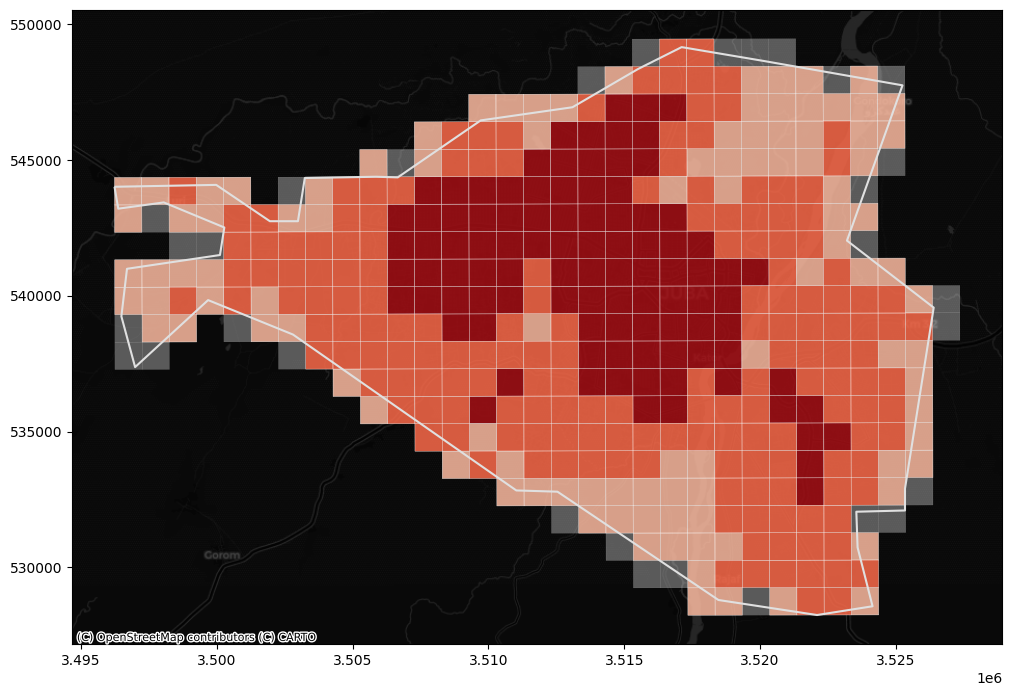

In [14]:
# Reproject to Web Mercator for contextily basemap
tiles_web = tiles.to_crs("EPSG:3857")
aoi_web   = aoi_4326.to_crs("EPSG:3857")

fig, ax = plt.subplots(figsize=(12, 12))

# Draw tiles, with separate styling for no-building tiles
for cls, grp in tiles_web.groupby("density_class"):
    if cls == "none":
        grp.plot(
            ax=ax,
            color=CLASS_COLORS[cls],
            edgecolor="white",
            linewidth=0.15,
            alpha=0.35,
            zorder=1,
        )
    else:
        grp.plot(
            ax=ax,
            color=CLASS_COLORS[cls],
            edgecolor="white",
            linewidth=0.3,
            alpha=0.85,
            zorder=2,
        )
# AOI boundary
aoi_web.boundary.plot(ax=ax, color="#e0e0e0", linewidth=1.5, zorder=5)

# Basemap
if HAS_CTX:
    try:
        ctx.add_basemap(
            ax,
            source=ctx.providers.CartoDB.DarkMatter,
            zoom="auto",
        )
    except Exception as e:
        print(f"Basemap failed ({e}); continuing without.")

# Legend — semantic labels only
CLASS_ORDER   = ["high", "medium", "low", "none"]
LEGEND_LABELS = {"high": "High", "medium": "Medium", "low": "Low", "none": "No buildings"}

legend_handles = []
for cls in CLASS_ORDER:
    if cls not in tiles["density_class"].values:
        continue
    alpha = 0.35 if cls == "none" else 0.85
    legend_handles.append(
        mpatches.Patch(color=CLASS_COLORS[cls], alpha=alpha, label=LEGEND_LABELS[cls])
    )

ax.legend(
    handles=legend_handles,
    title="Building density",
    title_fontsize=11,
    fontsize=10,
    loc="lower right",
    framealpha=0.85,
    facecolor="#1c1917",
    edgecolor="#555555",
    labelcolor="white",
    title_fontproperties={"size": 11, "weight": "bold"},
)

# Scale bar
try:
    ax.add_artist(ScaleBar(1, location="lower left", font_properties={"size": 9}))
except Exception:
    pass

ax.set_axis_off()
ax.set_title(
    f"Building density per 1 km × 1 km tile: {format_city_label(CITY_ID)}\n"
    f"({len(tiles):,} tiles · {len(ref_buildings):,} reference buildings)",
    fontsize=14,
    pad=14,
    color="white",
)
fig.patch.set_facecolor("#1c1917")

plt.tight_layout()
plt.show()

## 8. Interactive tile explorer (folium)

In [ ]:
# Reproject to WGS-84 for folium
tiles_4326 = tiles.to_crs("EPSG:4326")
aoi_latlon = aoi_4326

# Map centre
centroid   = aoi_4326.geometry.union_all().centroid
map_centre = [centroid.y, centroid.x]

m = folium.Map(
    location=map_centre,
    zoom_start=13,
    tiles="CartoDB dark matter",
    control_scale=True,
)

# Tiles layer
def _style(feature):
    cls = feature["properties"]["density_class"]
    return {
        "fillColor":   CLASS_COLORS.get(cls, COLOR_NONE),
        "fillOpacity": 0.6,
        "color":       "white",
        "weight":      0.4,
    }

def _highlight(feature):
    return {"fillOpacity": 0.85, "weight": 1.5, "color": "#e0e0e0"}

folium.GeoJson(
    tiles_4326,
    name="Density tiles",
    style_function=_style,
    highlight_function=_highlight,
    tooltip=folium.GeoJsonTooltip(
        fields=["tile_id", "n_buildings", "buildings_per_km2", "area_km2", "density_class"],
        aliases=["Tile ID", "Buildings", "Density (bldgs/km²)", "Area (km²)", "Class"],
        localize=True,
        sticky=True,
        style="font-size: 12px;",
    ),
).add_to(m)

# AOI boundary
folium.GeoJson(
    aoi_latlon,
    name="AOI boundary",
    style_function=lambda _: {
        "fillColor": "none",
        "color": "#e0e0e0",
        "weight": 2,
        "dashArray": "6 3",
    },
).add_to(m)

# Legend HTML — dark-themed
legend_html = """
<div style="
    position: fixed; bottom: 40px; right: 10px; z-index: 1000;
    background: #1c1917; padding: 12px 16px; border-radius: 8px;
    box-shadow: 0 2px 8px rgba(0,0,0,.6); font-size: 12px; line-height: 1.8;
    color: #e0e0e0; border: 1px solid #555555;
">
  <b>Building density</b><br>
  <span style='color:{high};font-size:18px;'>&#9632;</span>&nbsp;High<br>
  <span style='color:{med};font-size:18px;'>&#9632;</span>&nbsp;Medium<br>
  <span style='color:{low};font-size:18px;'>&#9632;</span>&nbsp;Low<br>
  <span style='color:{none};font-size:18px;'>&#9632;</span>&nbsp;No buildings
</div>
""".format(high=COLOR_HIGH, med=COLOR_MED, low=COLOR_LOW, none=COLOR_NONE)

m.get_root().html.add_child(folium.Element(legend_html))

folium.LayerControl(collapsed=False).add_to(m)
MiniMap(toggle_display=True).add_to(m)

m

## 9. Export tile GeoPackage (optional)

Save the annotated tile grid so it can be loaded in QGIS or shared with collaborators.

In [ ]:
OUT_DIR  = ROOT / "outputs" / "metrics" / CITY_ID
OUT_DIR.mkdir(parents=True, exist_ok=True)

city_slug  = CITY_ID.replace("-", "_")
out_path   = OUT_DIR / f"{city_slug}_tile_density.gpkg"

tiles_4326[
    ["tile_id", "n_buildings", "buildings_per_km2", "area_km2", "density_class", "geometry"]
].to_file(out_path, driver="GPKG")

print(f"Saved → {out_path}")

Saved → /content/drive/MyDrive/Gates Foundation/Building Dataset Validation/outputs/metrics/ssd-juba/ssd_juba_tile_density.gpkg
